# Exploratory Data Analysis — Garment Worker Productivity

**Dataset:** UCI ML Repository #597 — Garment Worker Productivity  
**Target variable:** `actual_productivity` (continuous, 0–1)  
**Notebook type:** COMPLETE REFERENCE VERSION  

---

## Structure
- **Part 1 — Univariate Analysis** (Sections 1–6)
- **Part 2 — Multivariate Analysis** (Sections 7–10)

---
# PART 1 — UNIVARIATE ANALYSIS

## Section 1: Load the Dataset

In [26]:
# ── Section 1: Load the Dataset ──────────────────────────
import subprocess, sys

# Install ucimlrepo if needed
try:
    import ucimlrepo
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ucimlrepo', '-q'])

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from ucimlrepo import fetch_ucirepo

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PALETTE = 'viridis'
target_col = 'actual_productivity'

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [27]:
# ── Fetch dataset from UCI ML Repository ─────────────────
repo = fetch_ucirepo(id=597)
df = pd.concat([repo.data.features, repo.data.targets], axis=1)

print(f'Raw dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Raw dataset shape: (1197, 15)
Columns: ['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']


In [28]:
# ── Preprocessing ─────────────────────────────────────────
# Drop 'date' column — not useful for EDA modelling
df = df.drop(columns=['date'], errors='ignore')

# Derive binary feature: has_incentive
df['has_incentive'] = (df['incentive'] > 0).astype(int)

# Keep 'incentive' column as well (not dropped per spec)
print('Preprocessing complete.')
print(f'Final shape: {df.shape}')

Preprocessing complete.
Final shape: (1197, 15)


In [29]:
# ── Basic inspection ──────────────────────────────────────
print('=== First 10 rows ===')
display(df.head(10))

print(f'\n=== Shape: {df.shape} ===')

print('\n=== Data Types ===')
display(df.dtypes.to_frame('dtype'))

print('\n=== Dataset Info ===')
df.info()

=== First 10 rows ===


,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,has_incentive
0,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,1
1,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,0
2,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,1
3,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,1
4,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,1
5,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125,1
6,Quarter1,finishing,Thursday,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.755167,0
7,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683,1
8,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098,1
9,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428,1



=== Shape: (1197, 15) ===

=== Data Types ===


,dtype
quarter,object
department,object
day,object
team,int64
targeted_productivity,float64
smv,float64
wip,float64
over_time,int64
incentive,int64
idle_time,float64



=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   team                   1197 non-null   int64  
 4   targeted_productivity  1197 non-null   float64
 5   smv                    1197 non-null   float64
 6   wip                    691 non-null    float64
 7   over_time              1197 non-null   int64  
 8   incentive              1197 non-null   int64  
 9   idle_time              1197 non-null   float64
 10  idle_men               1197 non-null   int64  
 11  no_of_style_change     1197 non-null   int64  
 12  no_of_workers          1197 non-null   float64
 13  actual_productivity    1197 non-null   float64
 14  has_incentive          1197 non-nu

In [30]:
# ── Programmatic column detection ─────────────────────────
numeric_cols = [
    c for c in df.columns
    if df[c].dtype in ['float64', 'int64', 'float32', 'int32']
    and df[c].nunique() > 10
    and c != target_col
]

binary_cols = [
    c for c in df.columns
    if df[c].nunique() == 2
    and c != target_col
]

categorical_cols = [
    c for c in df.columns
    if (df[c].dtype == 'object' or str(df[c].dtype) == 'category')
    and df[c].nunique() > 2
    and c != target_col
]

# ── Manual corrections ─────────────────────────────────────
# 'team' is an integer label (1–12), not a measured quantity.
# The programmatic rule captured it because dtype==int64 and nunique==12>10,
# but computing its mean, skewness, or Pearson r with productivity is meaningless.
# We treat it as ordinal by numeric order (1 < 2 < ... < 12) because we do not
# know which department each team belongs to — numeric ordering is the only
# defensible choice.
numeric_cols = [c for c in numeric_cols if c != 'team']

# Manual sub-lists: ordinal and nominal (subsets of all categorical variables)
ordinal_cols = ['day', 'quarter', 'no_of_style_change', 'team']
nominal_cols  = ['department']

# 'no_of_style_change' takes only {0, 1, 2} — discrete count with a natural order.
# 'targeted_productivity' is also discrete (management-set shift targets such as
# 0.70 / 0.75 / 0.80) but stored as float; it is flagged as near-constant in §2
# and noted there. 'idle_men' is similarly near-constant and noted in §2.
ordinal_order = {
    'day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'],
    'quarter': ['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5'],
    'no_of_style_change': [0, 1, 2],
    'team': list(range(1, 13)),
}

print('Numeric columns  :', numeric_cols)
print('Binary columns   :', binary_cols)
print('Categorical cols :', categorical_cols)
print('Ordinal cols     :', ordinal_cols)
print('Nominal cols     :', nominal_cols)
print('Target           :', target_col)

Numeric columns  : ['smv', 'wip', 'over_time', 'incentive', 'idle_time', 'no_of_workers']
Binary columns   : ['department', 'has_incentive']
Categorical cols : ['quarter', 'day']
Ordinal cols     : ['day', 'quarter', 'no_of_style_change', 'team']
Nominal cols     : ['department']
Target           : actual_productivity


## Section 2: Data Quality

=== Columns with missing values ===


,n_missing,pct_missing
wip,506,42.27


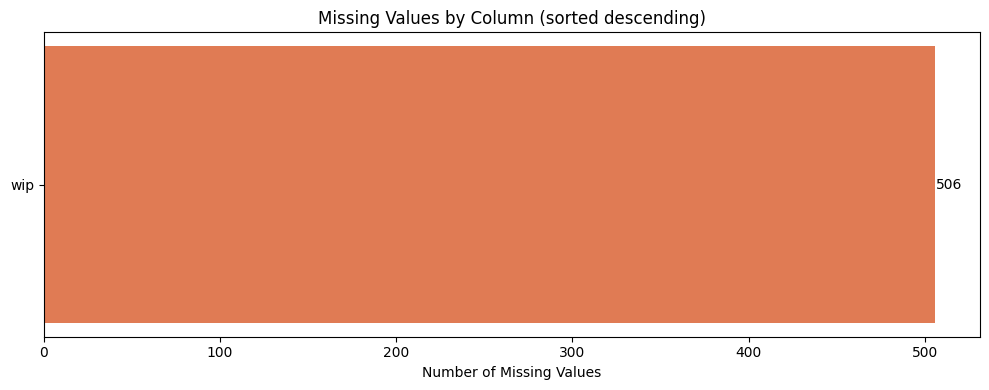

In [31]:
# ── Section 2: Data Quality ───────────────────────────────

# Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_df = missing_df[missing_df['n_missing'] >= 1].sort_values('n_missing', ascending=False)

print('=== Columns with missing values ===')
display(missing_df)

# Horizontal bar chart for missing values
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(missing_df.index, missing_df['n_missing'], color='#E07B54')
    ax.set_xlabel('Number of Missing Values')
    ax.set_title('Missing Values by Column (sorted descending)')
    for bar, val in zip(bars, missing_df['n_missing']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val}', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print('No columns have missing values.')

In [32]:
# ── Duplicate rows ────────────────────────────────────────
n_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {n_duplicates}')

# ── Near-constant columns ─────────────────────────────────
near_constant = [
    c for c in df.columns
    if df[c].nunique() / len(df) < 0.01
]
print(f'Near-constant columns (nunique/n < 0.01): {near_constant}')

# ── Data quality summary ──────────────────────────────────
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
summary_str = (
    f'\n====== DATA QUALITY SUMMARY ======\n'
    f'  Rows              : {df.shape[0]}\n'
    f'  Columns           : {df.shape[1]}\n'
    f'  Total cells       : {total_cells}\n'
    f'  Missing cells     : {total_missing} ({100*total_missing/total_cells:.2f}%)\n'
    f'  Duplicate rows    : {n_duplicates}\n'
    f'  Near-constant cols: {len(near_constant)} — {near_constant}\n'
    f'  Data quality note : "department" column uses "sweing" (typo for "sewing") — original data kept as-is\n'
    f'=================================='
)
print(summary_str)

Number of duplicate rows: 0
Near-constant columns (nunique/n < 0.01): ['quarter', 'department', 'day', 'targeted_productivity', 'idle_men', 'no_of_style_change', 'has_incentive']

====== DATA QUALITY SUMMARY ======
  Rows              : 1197
  Columns           : 15
  Total cells       : 17955
  Missing cells     : 506 (2.82%)
  Duplicate rows    : 0
  Near-constant cols: 7 — ['quarter', 'department', 'day', 'targeted_productivity', 'idle_men', 'no_of_style_change', 'has_incentive']
  Data quality note : "department" column uses "sweing" (typo for "sewing") — original data kept as-is


### Data Quality Notes

- **`wip` (work in progress)**: contains real NaN values from the original dataset. These represent missing production records and should be handled carefully before modelling.
- **`department` typo**: The value `'sweing'` is a misspelling of `'sewing'` present in the original UCI dataset. It is kept as-is to reflect the raw data faithfully, but flagged as a data quality finding.
- **Near-constant columns** may carry little discriminatory power and could be candidates for removal in feature selection.

## Section 3: Variable Examination

In [33]:
# ── Section 3: Variable Examination ──────────────────────

# Include target in numeric summary
all_numeric = numeric_cols + [target_col]

# Numeric summary
numeric_summary = pd.DataFrame({
    'name': all_numeric,
    'dtype': [str(df[c].dtype) for c in all_numeric],
    'min': [df[c].min() for c in all_numeric],
    'max': [df[c].max() for c in all_numeric],
    'mean': [round(df[c].mean(), 4) for c in all_numeric],
    'pct_missing': [round(df[c].isnull().mean() * 100, 2) for c in all_numeric]
})
print('=== Numeric Variables ===')
display(numeric_summary.set_index('name'))

=== Numeric Variables ===


,dtype,min,max,mean,pct_missing
name,,,,,
smv,float64,2.900000,54.560000,15.0622,0.00
wip,float64,7.000000,23122.000000,1190.4660,42.27
over_time,int64,0.000000,25920.000000,4567.4603,0.00
incentive,int64,0.000000,3600.000000,38.2105,0.00
idle_time,float64,0.000000,300.000000,0.7302,0.00
no_of_workers,float64,2.000000,89.000000,34.6099,0.00
actual_productivity,float64,0.233705,1.120437,0.7351,0.00


In [34]:
# Categorical summary (all categorical including ordinal and nominal)
all_cat = categorical_cols  # includes ordinal + nominal from object dtype

cat_summary = pd.DataFrame({
    'name': all_cat,
    'n_unique': [df[c].nunique() for c in all_cat],
    'most_frequent_value': [df[c].value_counts().idxmax() for c in all_cat],
    'pct_missing': [round(df[c].isnull().mean() * 100, 2) for c in all_cat]
})
print('=== Categorical Variables ===')
display(cat_summary.set_index('name'))

=== Categorical Variables ===


,n_unique,most_frequent_value,pct_missing
name,,,
quarter,5,Quarter1,0.0
day,6,Wednesday,0.0


In [35]:
# Binary summary
print('=== Binary Variables ===')
for col in binary_cols:
    vc = df[col].value_counts(normalize=True).round(4) * 100
    classes = vc.index.tolist()
    pcts = vc.values.tolist()
    parts = ' | '.join([f'Class {cls}: {pct:.1f}%' for cls, pct in zip(classes, pcts)])
    missing_pct_bin = round(df[col].isnull().mean() * 100, 2)
    print(f'  {col:20s} -> {parts}  (missing: {missing_pct_bin}%)')

=== Binary Variables ===
  department           -> Class sweing: 57.7% | Class finishing: 42.3%  (missing: 0.0%)
  has_incentive        -> Class 0: 50.5% | Class 1: 49.5%  (missing: 0.0%)


## Section 4: Graphical Exploration

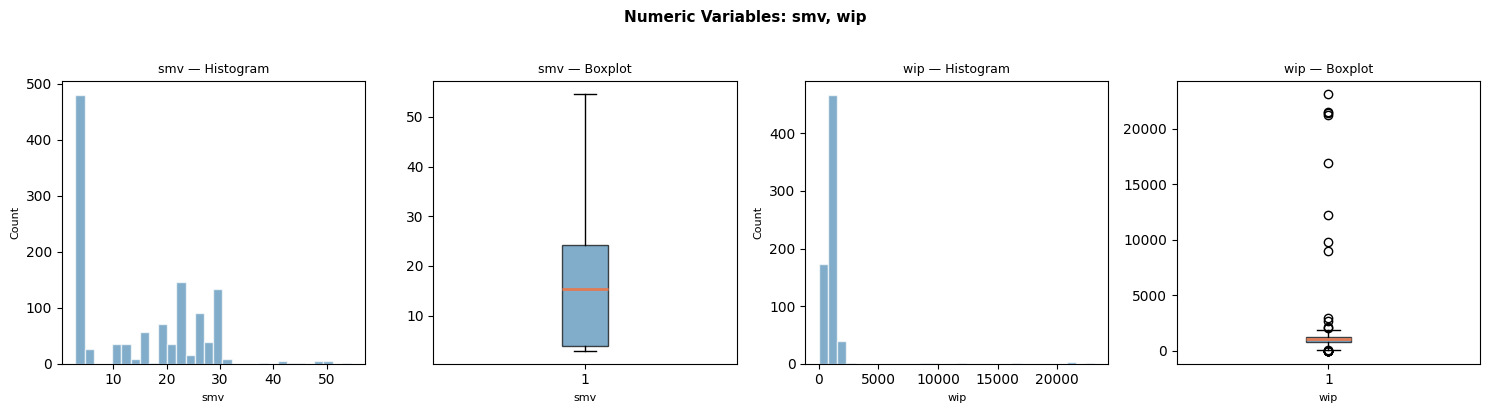

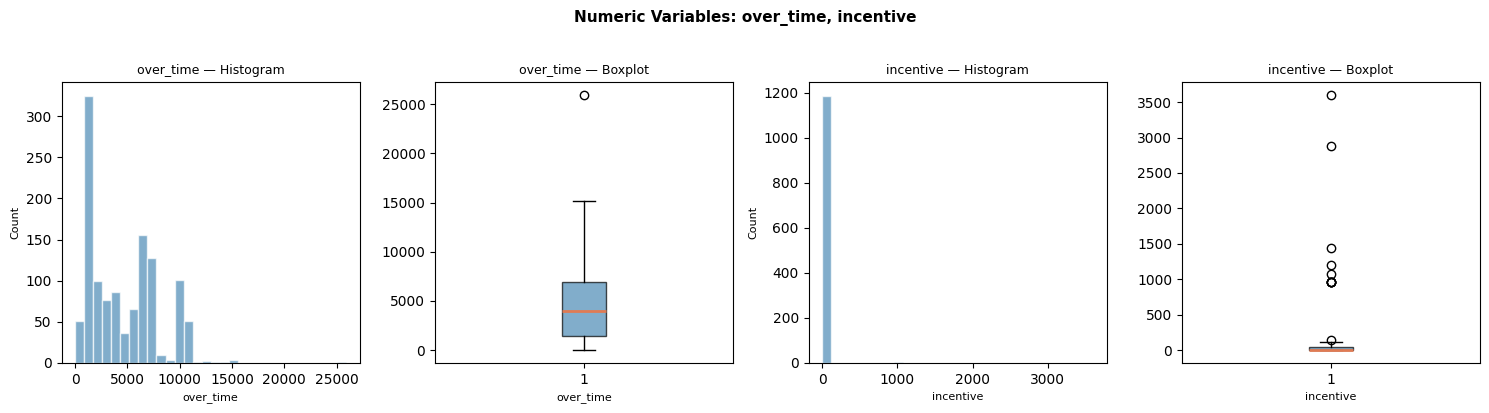

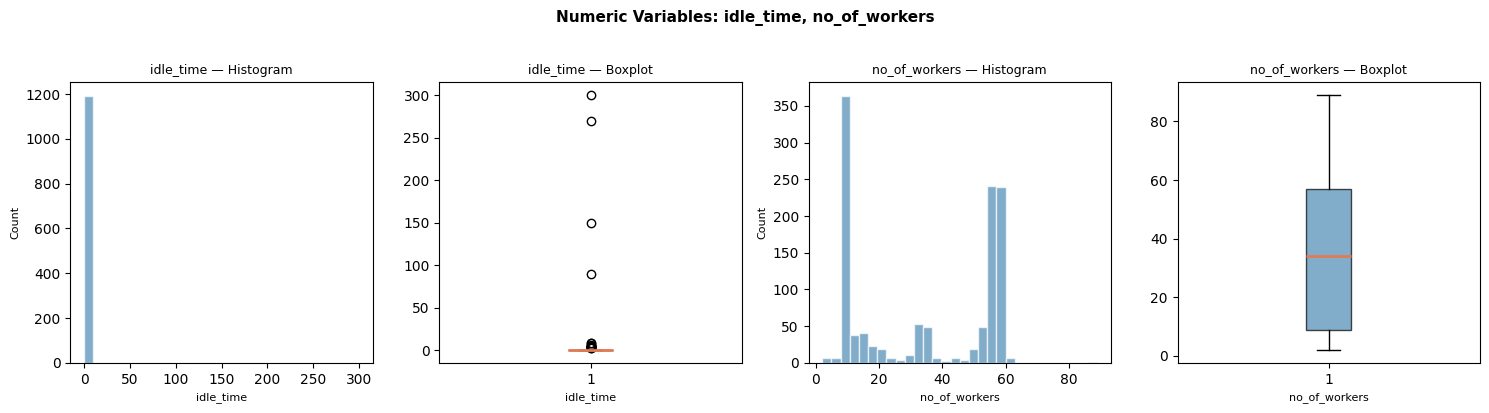

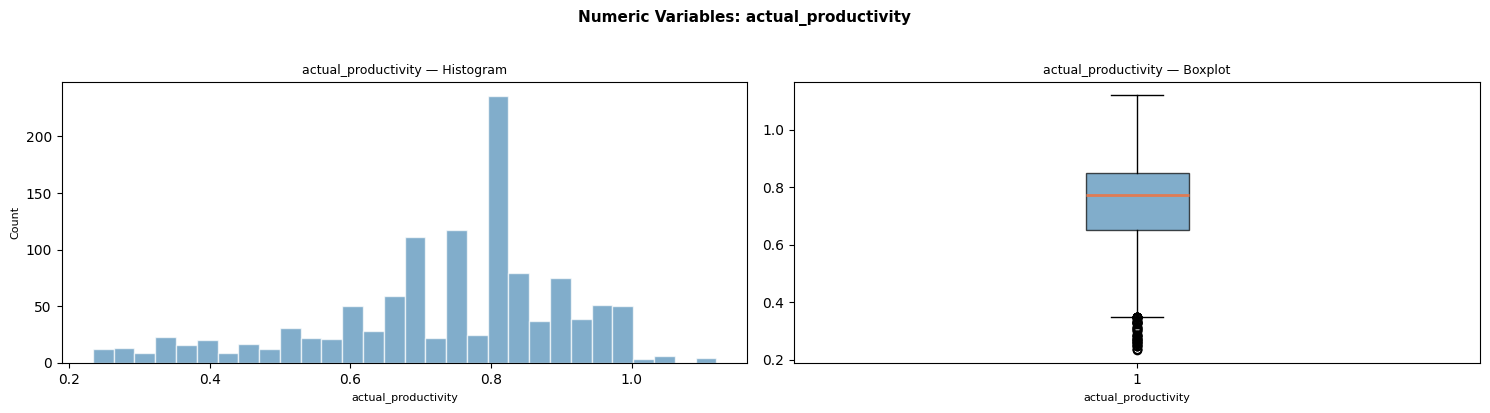

In [36]:
# ── Section 4: Graphical Exploration ─────────────────────
# Numeric variables: histogram (left) and boxplot (right)
# 2 variables per row → 4 subplots per row (2 pairs)

all_numeric_plot = numeric_cols + [target_col]
n_vars = len(all_numeric_plot)
vars_per_row = 2  # 2 variables side by side, each with 2 subplots

for row_start in range(0, n_vars, vars_per_row):
    row_vars = all_numeric_plot[row_start: row_start + vars_per_row]
    n_cols_fig = len(row_vars) * 2  # 2 plots per variable
    fig, axes = plt.subplots(1, n_cols_fig, figsize=(15, 4))
    if n_cols_fig == 1:
        axes = [axes]

    for i, col in enumerate(row_vars):
        ax_hist = axes[i * 2]
        ax_box  = axes[i * 2 + 1]

        data_clean = df[col].dropna()

        # Histogram
        ax_hist.hist(data_clean, bins=30, color='#4C8BB5', alpha=0.7, edgecolor='white')
        ax_hist.set_title(f'{col} — Histogram', fontsize=9)
        ax_hist.set_xlabel(col, fontsize=8)
        ax_hist.set_ylabel('Count', fontsize=8)

        # Boxplot
        ax_box.boxplot(data_clean, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#4C8BB5', alpha=0.7),
                       medianprops=dict(color='#E07B54', linewidth=2))
        ax_box.set_title(f'{col} — Boxplot', fontsize=9)
        ax_box.set_xlabel(col, fontsize=8)

    fig.suptitle(
        f'Numeric Variables: {", ".join(row_vars)}',
        fontsize=11, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()
    plt.close()

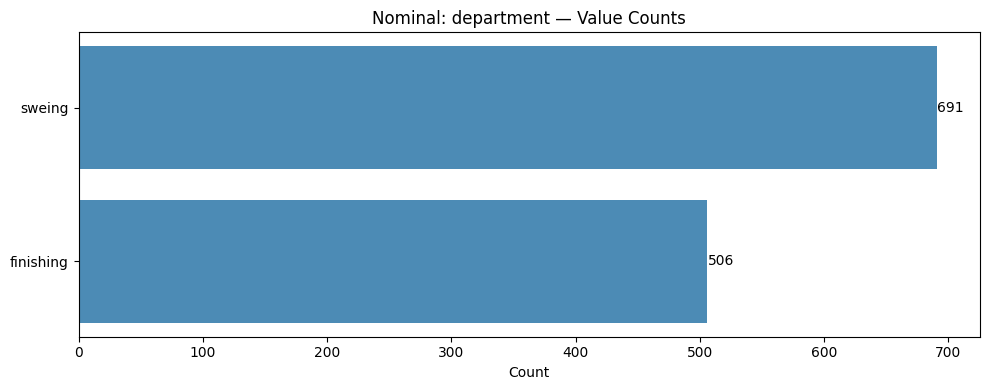

In [37]:
# ── Nominal categorical: horizontal bar chart sorted descending ──
for col in nominal_cols:
    vc = df[col].value_counts().sort_values(ascending=True)  # ascending for horizontal barh
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(vc.index.astype(str), vc.values, color='#4C8BB5')
    ax.set_title(f'Nominal: {col} — Value Counts', fontsize=12)
    ax.set_xlabel('Count')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

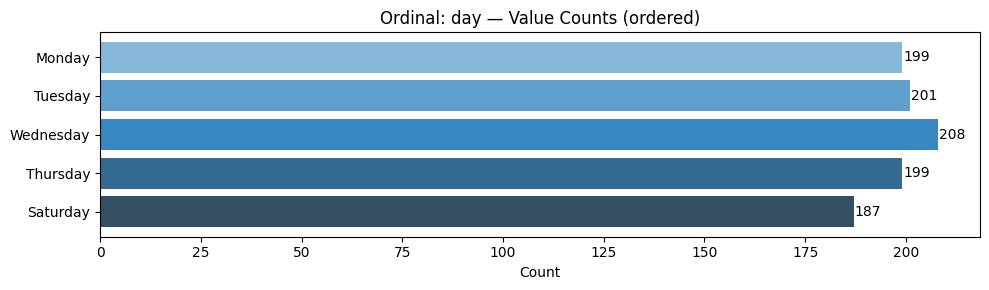

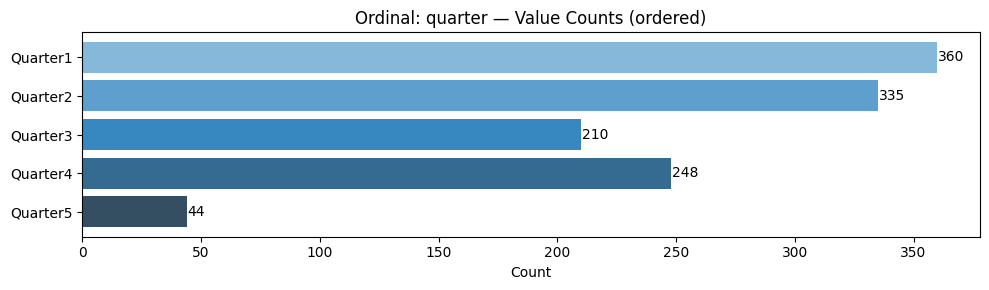

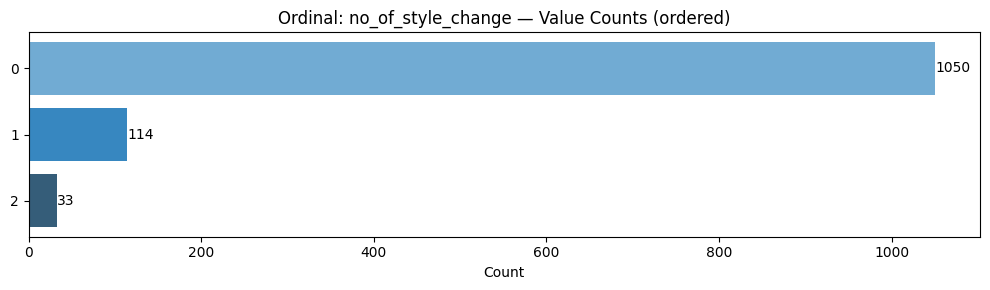

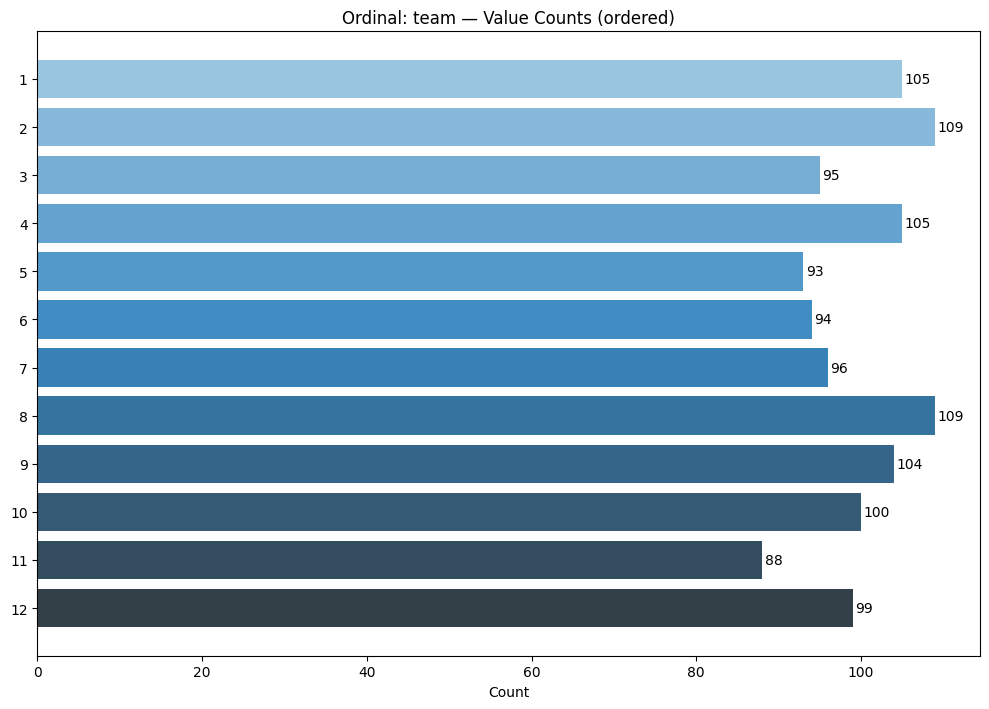

In [38]:
# ── Ordinal categorical: horizontal bar chart in ordinal order ───
for col in ordinal_cols:
    order = ordinal_order[col]
    vc = df[col].value_counts()

    # Only include categories present in data
    present_cats = [c for c in order if c in vc.index]
    present_vals = [vc[c] for c in present_cats]

    # Convert to strings so matplotlib renders them as category labels,
    # not as numeric axis positions (matters for integer-coded columns
    # like 'no_of_style_change' and 'team').
    label_cats = [str(c) for c in present_cats]

    # Sequential palette
    n = len(present_cats)
    palette = sns.color_palette('Blues_d', n_colors=n)

    fig, ax = plt.subplots(figsize=(10, max(3, n * 0.6)))
    bars = ax.barh(label_cats, present_vals, color=palette)
    ax.set_title(f'Ordinal: {col} — Value Counts (ordered)', fontsize=12)
    ax.set_xlabel('Count')
    ax.invert_yaxis()  # lowest ordinal at top
    for bar, val in zip(bars, present_vals):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

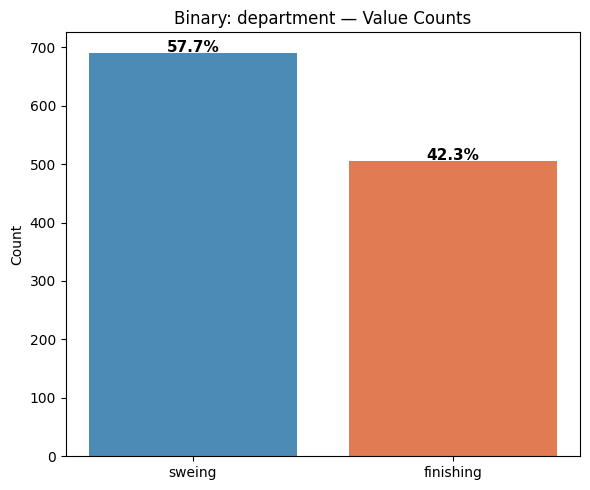

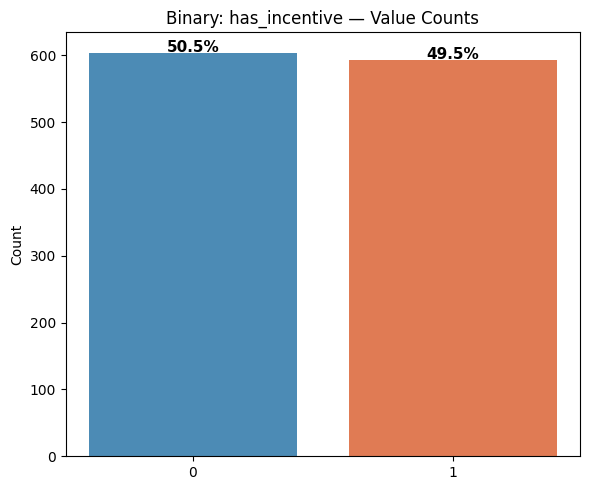

In [39]:
# ── Binary: vertical bar chart with % labels ──────────────
for col in binary_cols:
    vc = df[col].value_counts()
    pct = (df[col].value_counts(normalize=True) * 100).round(1)

    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(vc.index.astype(str), vc.values, color=['#4C8BB5', '#E07B54'])
    ax.set_title(f'Binary: {col} — Value Counts', fontsize=12)
    ax.set_ylabel('Count')
    for bar, (cls, p) in zip(bars, pct.items()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{p}%', ha='center', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

## Section 5: Descriptive Statistics + Skewness + Kurtosis

In [40]:
# ── Section 5: Descriptive Statistics ────────────────────
desc = df.describe(include='all')
print('=== describe(include="all") ===')
display(desc)

=== describe(include="all") ===


,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,has_incentive
count,1197,1197,1197,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
unique,5,2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Quarter1,sweing,Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,360,691,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091,0.495405
std,NaN,NaN,NaN,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488,0.500188
min,NaN,NaN,NaN,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705,0.000000
25%,NaN,NaN,NaN,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307,0.000000
50%,NaN,NaN,NaN,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333,0.000000
75%,NaN,NaN,NaN,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253,1.000000


### Interpreting `.describe()` rows

| Row | Meaning |
|-----|---------|
| `count` | Number of non-null observations |
| `unique` | Number of unique values (categorical only) |
| `top` | Most frequent value (categorical only) |
| `freq` | Frequency of the most common value (categorical only) |
| `mean` | Arithmetic mean (numeric only) |
| `std` | Standard deviation — spread around the mean |
| `min` | Minimum observed value |
| `25%` | First quartile (Q1) — 25% of values fall below this |
| `50%` | Median (Q2) — robust central tendency |
| `75%` | Third quartile (Q3) — 75% of values fall below this |
| `max` | Maximum observed value |

In [41]:
# ── Skewness & Kurtosis computation ───────────────────────
def skew_label(s):
    s = abs(s)
    if s < 0.5:
        return 'symmetric'
    elif s < 1.0:
        return 'moderate skew'
    else:
        return 'high skew'

def kurt_label(k):
    """k is Fisher excess kurtosis (scipy default)."""
    if k > 1.0:
        return 'leptokurtic'
    elif k < -1.0:
        return 'platykurtic'
    else:
        return 'mesokurtic'

skew_kurt_rows = []
for col in all_numeric_plot:
    data_clean = df[col].dropna()
    skewness = data_clean.skew()
    kurtosis = data_clean.kurt()  # Fisher excess kurtosis
    skew_kurt_rows.append({
        'column': col,
        'skewness': round(skewness, 4),
        'skew_interpretation': skew_label(skewness),
        'kurtosis': round(kurtosis, 4),
        'kurt_interpretation': kurt_label(kurtosis)
    })

sk_df = pd.DataFrame(skew_kurt_rows).set_index('column')
display(sk_df)

,skewness,skew_interpretation,kurtosis,kurt_interpretation
column,,,,
smv,0.4059,symmetric,-0.7953,mesokurtic
wip,9.7418,high skew,101.7020,leptokurtic
over_time,0.6733,moderate skew,0.4244,mesokurtic
incentive,15.7907,high skew,299.0325,leptokurtic
idle_time,20.5454,high skew,442.6382,leptokurtic
no_of_workers,-0.1117,symmetric,-1.7881,platykurtic
actual_productivity,-0.8075,moderate skew,0.3332,mesokurtic


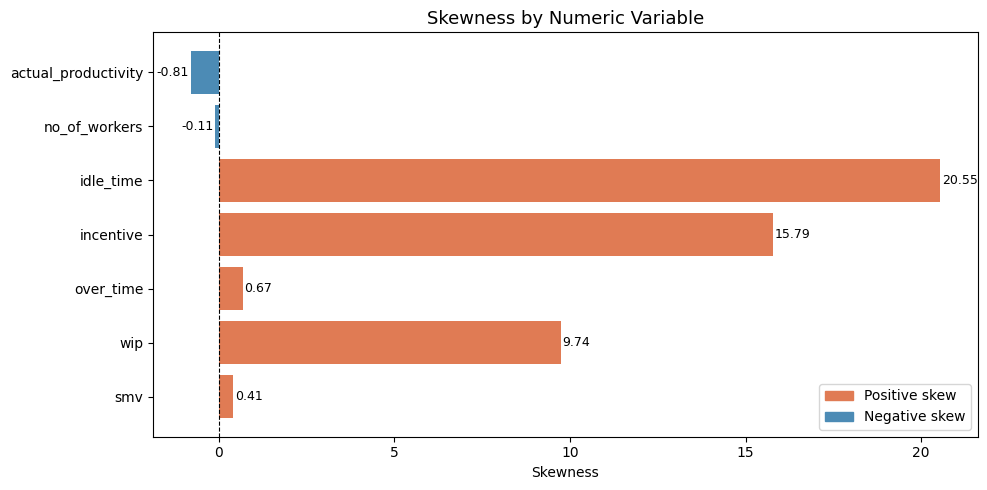

In [42]:
# ── Skewness bar chart ────────────────────────────────────
skew_vals = sk_df['skewness']
colors_skew = ['#E07B54' if v >= 0 else '#4C8BB5' for v in skew_vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(skew_vals.index, skew_vals.values, color=colors_skew)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Skewness by Numeric Variable', fontsize=13)
ax.set_xlabel('Skewness')
for bar, val in zip(bars, skew_vals.values):
    x_pos = bar.get_width() + (0.05 if val >= 0 else -0.05)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)

coral_patch = mpatches.Patch(color='#E07B54', label='Positive skew')
blue_patch = mpatches.Patch(color='#4C8BB5', label='Negative skew')
ax.legend(handles=[coral_patch, blue_patch], loc='lower right')
plt.tight_layout()
plt.show()
plt.close()

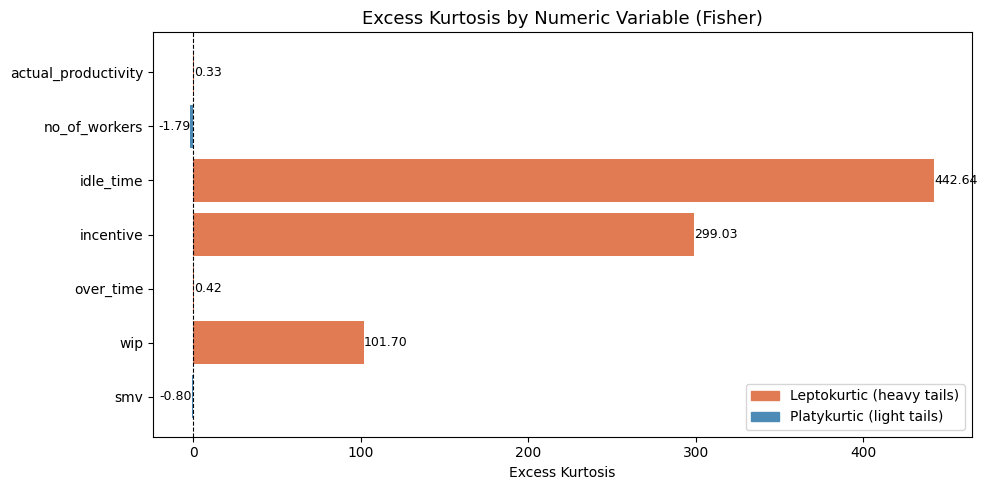

In [43]:
# ── Kurtosis bar chart ────────────────────────────────────
kurt_vals = sk_df['kurtosis']
colors_kurt = ['#E07B54' if v >= 0 else '#4C8BB5' for v in kurt_vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(kurt_vals.index, kurt_vals.values, color=colors_kurt)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Excess Kurtosis by Numeric Variable (Fisher)', fontsize=13)
ax.set_xlabel('Excess Kurtosis')
for bar, val in zip(bars, kurt_vals.values):
    x_pos = bar.get_width() + (0.1 if val >= 0 else -0.1)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)

lep_patch = mpatches.Patch(color='#E07B54', label='Leptokurtic (heavy tails)')
pla_patch = mpatches.Patch(color='#4C8BB5', label='Platykurtic (light tails)')
ax.legend(handles=[lep_patch, pla_patch], loc='lower right')
plt.tight_layout()
plt.show()
plt.close()

## Section 6: Outlier Detection

In [44]:
# ── Section 6: Outlier Detection ─────────────────────────
outlier_rows = []
for col in all_numeric_plot:
    data_clean = df[col].dropna()
    q1 = data_clean.quantile(0.25)
    q3 = data_clean.quantile(0.75)
    iqr = q3 - q1

    lower_mild = q1 - 1.5 * iqr
    upper_mild = q3 + 1.5 * iqr
    lower_extreme = q1 - 3.5 * iqr
    upper_extreme = q3 + 3.5 * iqr

    n_mild = ((data_clean < lower_mild) | (data_clean > upper_mild)).sum()
    n_extreme = ((data_clean < lower_extreme) | (data_clean > upper_extreme)).sum()

    n = len(data_clean)
    outlier_rows.append({
        'column': col,
        'n_mild': int(n_mild),
        'n_extreme': int(n_extreme),
        'pct_mild': round(100 * n_mild / n, 2),
        'pct_extreme': round(100 * n_extreme / n, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).set_index('column').sort_values('n_mild', ascending=False)
print('=== Outlier Summary ===')
display(outlier_summary)

=== Outlier Summary ===


,n_mild,n_extreme,pct_mild,pct_extreme
column,,,,
actual_productivity,54,0,4.51,0.00
wip,22,9,3.18,1.30
idle_time,18,18,1.50,1.50
incentive,11,10,0.92,0.84
over_time,1,0,0.08,0.00
smv,0,0,0.00,0.00
no_of_workers,0,0,0.00,0.00


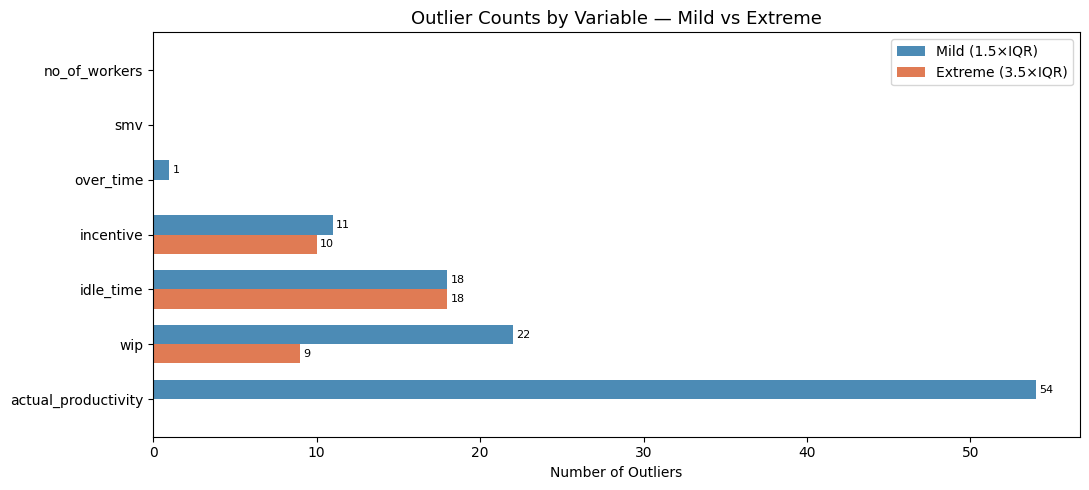

In [45]:
# ── Grouped horizontal bar chart: mild vs extreme outliers ─
cols_out = outlier_summary.index.tolist()
n_out = len(cols_out)
y = np.arange(n_out)
bar_height = 0.35

fig, ax = plt.subplots(figsize=(11, max(5, n_out * 0.55)))

bars_mild = ax.barh(y + bar_height / 2, outlier_summary['n_mild'], bar_height,
                    color='#4C8BB5', label='Mild (1.5×IQR)')
bars_ext = ax.barh(y - bar_height / 2, outlier_summary['n_extreme'], bar_height,
                   color='#E07B54', label='Extreme (3.5×IQR)')

ax.set_yticks(y)
ax.set_yticklabels(cols_out)
ax.set_xlabel('Number of Outliers')
ax.set_title('Outlier Counts by Variable — Mild vs Extreme', fontsize=13)
ax.legend()

for bar in bars_mild:
    if bar.get_width() > 0:
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                str(int(bar.get_width())), va='center', fontsize=8)
for bar in bars_ext:
    if bar.get_width() > 0:
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                str(int(bar.get_width())), va='center', fontsize=8)

plt.tight_layout()
plt.show()
plt.close()

---
# PART 2 — MULTIVARIATE ANALYSIS

## Section 7: Correlation Heatmap

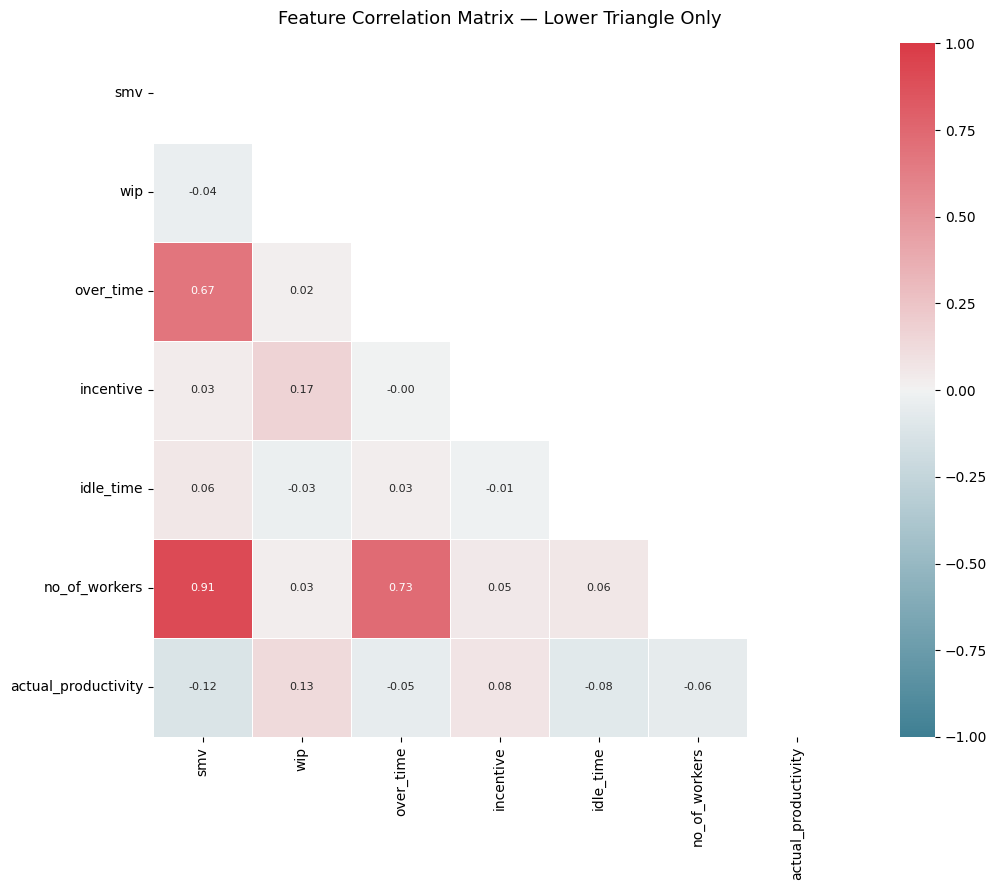

In [46]:
# ── Section 7: Correlation Heatmap ───────────────────────
# Only numeric cols (exclude binary and categorical)
heatmap_cols = numeric_cols + [target_col]
corr = df[heatmap_cols].corr(method='pearson')

# Mask upper triangle including diagonal
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Feature Correlation Matrix — Lower Triangle Only', fontsize=13, pad=14)
plt.tight_layout()
plt.show()
plt.close()

## Section 8: Feature Correlation with Target

In [47]:
# ── Section 8: Feature Correlation with Target ────────────
# Binary cols (has_incentive, department) are excluded — Pearson r requires
# continuous, interval-scale variables; use point-biserial for binary inputs.
feature_cols = [c for c in numeric_cols if c != target_col]

target_corr = pd.Series(
    {col: df[[col, target_col]].dropna().corr().iloc[0, 1] for col in feature_cols},
    name='pearson_r'
).sort_values(ascending=False)

print(f'Feature correlations with target: "{target_col}"')
display(target_corr.to_frame())

Feature correlations with target: "actual_productivity"


,pearson_r
wip,0.131147
incentive,0.076538
over_time,-0.054206
no_of_workers,-0.057991
idle_time,-0.080851
smv,-0.122089


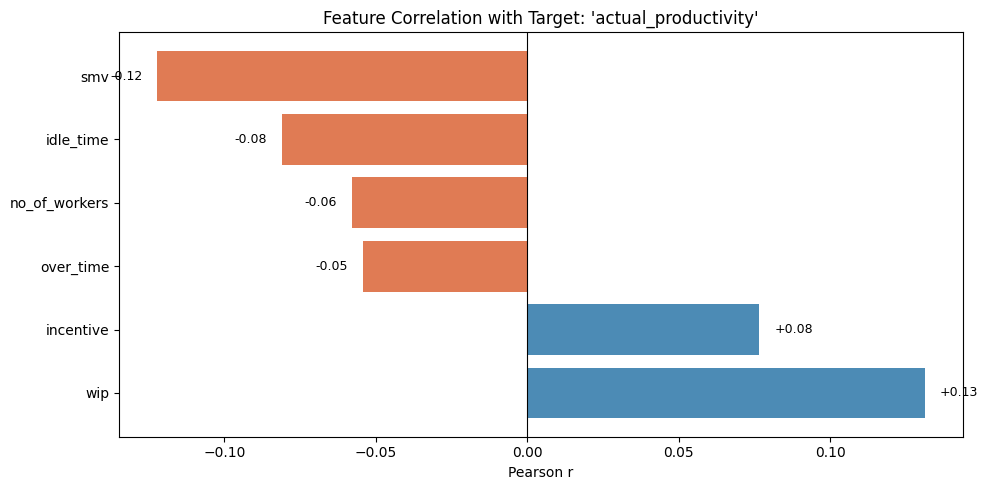

In [48]:
# ── Horizontal bar chart ──────────────────────────────────
bar_colors = ['#4C8BB5' if v >= 0 else '#E07B54' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, max(5, len(target_corr) * 0.45)))
bars = ax.barh(target_corr.index, target_corr.values, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r')
ax.set_title(f"Feature Correlation with Target: '{target_col}'", fontsize=12)

for bar, val in zip(bars, target_corr.values):
    label = f'+{val:.2f}' if val >= 0 else f'{val:.2f}'
    x_pos = bar.get_width() + (0.005 if val >= 0 else -0.005)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()
plt.close()

## Section 9: Scatter Plots

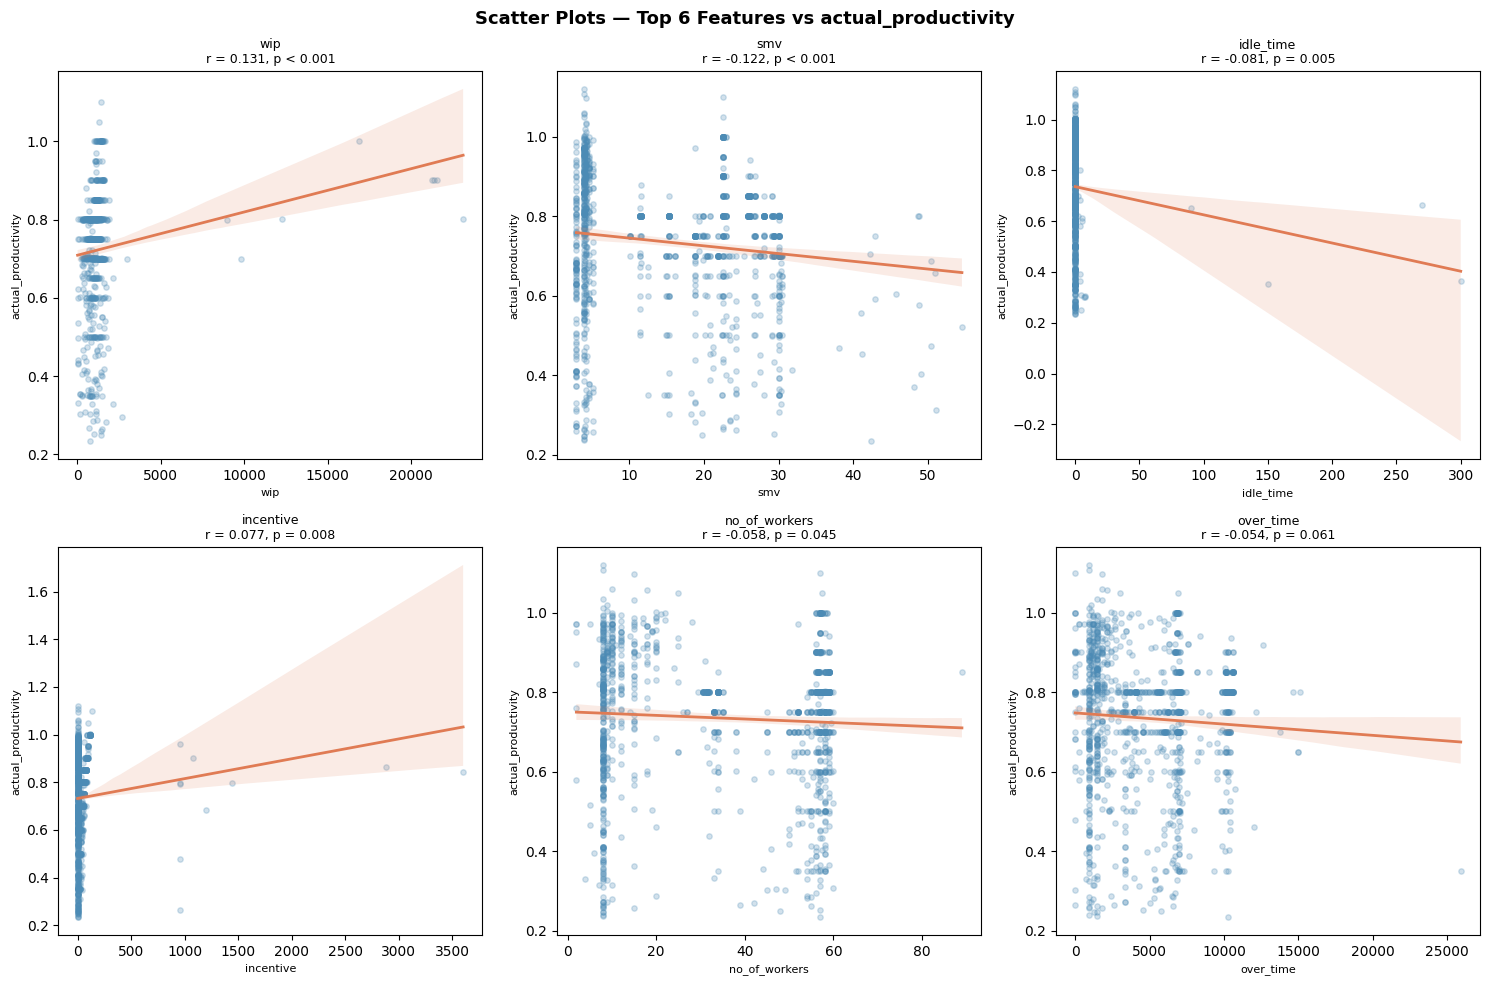

In [49]:
# ── Section 9: Scatter Plots (top-6 features) ────────────
top6_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(top6_features):
    ax = axes[i]
    temp = df[[feat, target_col]].dropna()

    # Compute r and p-value
    r_val, p_val = stats.pearsonr(temp[feat], temp[target_col])

    # Format p-value label
    if p_val < 0.001:
        p_label = 'p < 0.001'
    else:
        p_label = f'p = {p_val:.3f}'

    sns.regplot(
        data=temp, x=feat, y=target_col,
        ax=ax,
        scatter_kws={'alpha': 0.25, 's': 15, 'color': '#4C8BB5'},
        line_kws={'color': '#E07B54', 'linewidth': 2}
    )
    ax.set_title(f'{feat}\nr = {r_val:.3f}, {p_label}', fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(target_col, fontsize=8)

# Hide any unused axes
for j in range(len(top6_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Scatter Plots — Top 6 Features vs {target_col}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

## Section 10: YData Profiling

In [50]:
# ── Section 10: YData Profiling ───────────────────────────
try:
    from ydata_profiling import ProfileReport
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ydata-profiling', '-q'])
    from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    minimal=True,
    progress_bar=False,
    title='EDA Report — Garment Worker Productivity'
)

report_path = 'eda_report_demo.html'
profile.to_file(report_path)
print(f'YData Profiling report saved to: {report_path}')

100%|██████████| 15/15 [00:00<00:00, 984.72it/s]


YData Profiling report saved to: eda_report_demo.html


### What YData Profiling automates

YData Profiling (formerly `pandas-profiling`) generates an interactive HTML report that automatically covers:

- **Variable-level statistics**: type detection, distinct counts, missing values, zeros, infinite values
- **Distributions**: histograms for numeric variables, frequency tables for categoricals
- **Correlations**: multiple methods (Pearson, Spearman, Cramér's V, Phik) in a single heatmap
- **Interactions**: pairwise scatter plots between numeric variables
- **Alerts**: flags for high cardinality, imbalanced classes, skewed variables, high correlations, and constant features
- **Missing value analysis**: heatmap, dendrogram, and bar chart of missingness
- **Sample rows**: first and last N rows

### What it cannot replace

- **Domain-driven interpretation**: automated alerts require human judgment about which findings are meaningful in context (e.g., whether a typo in `department` matters, or whether `wip` NaNs are truly random)
- **Custom visualisations**: grouped charts, ordinal ordering, or faceted plots tailored to specific research questions
- **Hypothesis testing**: it surfaces correlations but does not perform or interpret statistical tests for inference
- **Feature engineering decisions**: deriving `has_incentive` from `incentive`, handling outliers, or encoding ordinal variables requires deliberate choices not automated by profiling tools
- **Narrative and communication**: a profiling report is a data dump, not an analytical story — translating findings into actionable insights remains the analyst's responsibility